# Predicción de Precios de Vivienda en California y Abandono de Clientes en Banca

Proyecto de Machine Learning supervisado sobre dos dominios distintos: predicción del precio medio de vivienda en California y predicción de abandono de clientes (churn) en banca. El desafío plantea dos preguntas centrales: *¿cuánto vale una vivienda dado su contexto?* y *¿qué clientes están en riesgo real de abandonar el banco?*

Este notebook recorre el pipeline completo — desde carga de datos y análisis exploratorio hasta feature engineering, entrenamiento, evaluación y diagnóstico de errores — para responder ambas preguntas con el estricto Ritual de los 7 pasos y una redacción honesta de los hallazgos: qué funciona, qué limita el modelo y cómo el propio RMSE nos mantiene humildes.


## Carga de datos

Trabajamos con dos datasets reales:

- **California Housing Prices**: precios de vivienda en California (1990) a nivel de bloque censal, con el target `median_house_value` en **dólares reales**. Cargamos la versión **curada (`housing_clean.csv`) producida en el proyecto anterior**: sin el techo artificial, sin outliers extremos en los ratios derivados y sin nulos.
- **Bank Customer Churn**: 10.000 clientes de un banco europeo con su indicador de abandono (`Exited`). Esos datos también llegan **curados**: el notebook `notebooks/churn_eda.ipynb` los explora (EDA) y exporta `data/processed/bank_churn_clean.csv` (sin nulos ni duplicados y con las categorías codificadas), que es lo que cargamos aquí.

El dataset curado de California vive en `data/processed/housing_clean.csv` (resume los hallazgos del proyecto anterior, ver sección de contexto); el de churn sale de `notebooks/churn_eda.ipynb` → `data/processed/bank_churn_clean.csv`.


In [1]:
#  Imports y Configuración 

# Importamos las librerías de análisis y visualización de datos.
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        

from sklearn.model_selection import train_test_split # Division de datos
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Estandarizacion y Conversion de datos
from sklearn.compose import ColumnTransformer # Tranformaciones distintas a columnas distintas a la vez
from sklearn.pipeline import Pipeline # Automatización del preprocesamiento y entrenamiento
from sklearn.impute import SimpleImputer # Imputacion de los datos faltantes
from sklearn.cluster import KMeans # Aprendizaje no supervisado
from sklearn.linear_model import LinearRegression, LogisticRegression # Algoritmos

from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, precision_score, 
                             recall_score, classification_report, confusion_matrix) # Metricas de Evaluacion de Modelos
from sklearn.metrics import ConfusionMatrixDisplay # Grafica la matriz de confusion (valores reales vs predicciones)

# Configuracion general
import warnings
warnings.filterwarnings('ignore')          
sns.set_theme(style='whitegrid')          

SEED = 42                                  # semilla fija (reproducibilidad)

# Carga de ambos Datasets
CAL = r'../data/processed/housing_clean.csv'   # dataset curado (regresión - California)
BNK_CLEAN = r'../data/processed/bank_churn_clean.csv'  # dataset curado (clasificación - Bank churn)

df_cal_clean = pd.read_csv(CAL)            # California ya limpio (C1DS)
df_bnk_clean = pd.read_csv(BNK_CLEAN)      # Bank Churn ya limpio (churn_eda.ipynb)

print('California Housing (curated):', df_cal_clean.shape[0], 'filas x', df_cal_clean.shape[1], 'columnas')
print('Bank Churn (curated)     :', df_bnk_clean.shape[0], 'filas x', df_bnk_clean.shape[1], 'columnas')


California Housing (curated): 19087 filas x 13 columnas
Bank Churn (curated)     : 10000 filas x 12 columnas


## Contexto: hallazgos clave del EDA

Antes de modelar, miremos los datos a la cara. Las decisiones de preparación se basan en lo que el análisis exploratorio revela, no en suposiciones.

### California Housing

Cargamos el dataset **ya curado del proyecto anterior** (`housing_clean.csv`, 19.087 bloques). Hallazgos que guiaron esa limpieza:

- **Techos artificiales detectados**: el target `median_house_value` está recortado en $500,001 (~4.7% de las filas), `housing_median_age` en 52 años (~6.2%) y `median_income` en ~15.0001 (~0.2%). Solo se filtró el **target**, porque truncar la variable objetivo corrompe el error del modelo; los otros dos son predictoras con correlación baja y su filtrado no justificaba perder datos.
- **Outliers de ratios recortados al p99**: `rooms_per_household`, `bedrooms_per_room` y `population_per_household` filtrados a su percentil 99 (outliers espaciales extremos). Resultado: 19.087 bloques **sin nulos**.
- **`median_income` es el predictor individual más fuerte** del precio (correlación de Pearson ~0.69), robusta en datos crudos y curados.
- **La geografía importa pero no linealmente**: el proyecto anterior reveló dos clusters de alto valor (Bahía de San Francisco y costa de Los Ángeles) invisibles a la correlación simple — por eso convertiremos las coordenadas en **zonas geográficas con K-Means**.
- **`ocean_proximity`** eleva el precio (`NEAR OCEAN`/`NEAR BAY` > `INLAND`), con `ISLAND` poco confiable (solo 5 bloques).
- **`bedrooms_per_room` revela un patrón oculto**: su correlación con el precio/ingreso es más fuerte que la de varias variables individuales, relación que los outliers ocultaban.

### Bank Churn

El EDA profundo de churn vive en **`notebooks/churn_eda.ipynb`**, que explora el dataset crudo y exporta la versión curada (`bank_churn_clean.csv`). Hallazgos clave de ese análisis:

- El dataset está **libre de nulos** (10.000 filas de clientes de un banco europeo).
- El target `Exited` está **desbalanceado** (79.63% se queda / 20.37% se va) — el baseline de Accuracy es ~79.63%, y el **Recall será clave** para detectar fugas.
- `Age` es el predictor más fuerte del churn: los clientes que se van tienen una edad media de **44.8 años** vs 37.4 de los que se quedan.
- `Geography` revela un patrón regional: **Alemania** concentra el 32% de las bajas, vs ~16% en Francia y España — `Geography_Germany` será un predictor relevante.
- `IsActiveMember` tiene un **efecto protector**: los miembros activos abandonan menos (promedio 0.64 en se queda vs 0.36 en se va).
- `NumOfProducts` tiene una relación **no lineal** con el churn (más de 2 productos se asocia a mayor fuga); se conserva numérico para que el modelo capture la señal dominante.

La curaduría exportada elimina los identificadores (`CustomerId`, `Surname`) y codifica `Geography`/`Gender` con one-hot sin redundancia (`drop_first`): `Geography_Germany`, `Geography_Spain` y `Gender_Male`.


In [2]:
# eda rapido: california housing (datos ya curados del proyecto C1DS)

print('\n========== EDA RÁPIDO: CALIFORNIA HOUSING (CURATED) ==========')
print(f'Dimensiones: {df_cal_clean.shape}')

print(f'\nNulos por columna:\n{df_cal_clean.isnull().sum()}')

# Verificamos que la limpieza del proyecto anterior se mantiene: sin techo artificial.
print('\nFilas con target == 500001 (techo artificial):', (df_cal_clean['median_house_value'] >= 500001).sum())
print(f'Rango del target: [{df_cal_clean["median_house_value"].min():,.0f}, {df_cal_clean["median_house_value"].max():,.0f}] USD')

# los modelos solo entienden números -> esto se tendrá que codificar (one-hot).
print('\nValores únicos en ocean_proximity:')
print(df_cal_clean['ocean_proximity'].value_counts())
print('\nRatios curados (muestra):')
print(df_cal_clean[['rooms_per_household', 'population_per_household', 'bedrooms_per_room']].head(3))



========== EDA RÁPIDO: CALIFORNIA HOUSING (CURATED) ==========
Dimensiones: (19087, 13)

Nulos por columna:
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
population_per_household    0
bedrooms_per_room           0
dtype: int64

Filas con target == 500001 (techo artificial): 0
Rango del target: [14,999, 500,000] USD

Valores únicos en ocean_proximity:
ocean_proximity
<1H OCEAN     8362
INLAND        6269
NEAR OCEAN    2389
NEAR BAY      2062
ISLAND           5
Name: count, dtype: int64

Ratios curados (muestra):
   rooms_per_household  population_per_household  bedrooms_per_room
0             6.984127                  2.555556           0.146591
1             6.238137                  2.109842           0.1

In [3]:
print('\n========== BANK CHURN: VERIFICACIÓN DEL DATASET CURADO ==========')
print('Dimensiones:', df_bnk_clean.shape)
print('Nulos restantes:', int(df_bnk_clean.isnull().sum().sum()))
print('\nDistribución del target Exited:')
print(df_bnk_clean['Exited'].value_counts(normalize=True).round(4).to_string())
print('\nColumnas finales:', df_bnk_clean.columns.tolist())



========== BANK CHURN: VERIFICACIÓN DEL DATASET CURADO ==========
Dimensiones: (10000, 12)
Nulos restantes: 0

Distribución del target Exited:
Exited
0    0.7963
1    0.2037

Columnas finales: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


## Feature engineering

Los datos de California ya vienen limpios del proyecto anterior — sin techo artificial y con los ratios derivados curados (`rooms_per_household`, `population_per_household`, `bedrooms_per_room`). Aquí aportamos el valor añadido de este desafío: la **cross feature `age_x_income`** (interacción antigüedad × ingreso, que captura un efecto sinérgico que ninguna variable ve por separado) y las **zonas geográficas con K-Means** sobre las coordenadas. La codificación de `ocean_proximity` la deja el pipeline.

Para **Bank Churn** cargamos el dataset curado del notebook de EDA y le añadimos **cross features con sentido económico**: `Balance_x_NumOfProducts` (dinero por producto contratado), `Tenure_per_Age` (proporción de la vida del cliente en el banco) y `Balance_per_Salary` (proporción del sueldo depositada).

In [4]:
print('Feature Engineering California')

# Trabajamos sobre una copia para no tocar el DataFrame base.
df_cal = df_cal_clean.copy()

# Cross Feature
df_cal['age_x_income'] = df_cal['housing_median_age'] * df_cal['median_income'] # el valor se dispara solo cuando ambos son altos al mismo tiempo.

# Zonas geograficas con K-Means: agrupamos los bloques por cercania geografica.
geo = df_cal[['latitude', 'longitude']].values   # matriz de ubicaciones

kmeans = KMeans(n_clusters=8, random_state=SEED, n_init=10) # proceso de agrupacion

df_cal['geo_zone'] = kmeans.fit_predict(geo) # Calcula las distancias y agrupa los distritos en 8 regiones.

geo = pd.get_dummies(df_cal['geo_zone'], prefix='geo_zone', drop_first=True).astype(int) # k-1: geo_zone_0 queda como referencia (multicolinealidad)

# Concatenamos las dummies geograficas al dataset.
df_cal = pd.concat([df_cal, geo], axis=1)

print('\nRatios curados + cross feature (muestra):')
print(df_cal[['rooms_per_household', 'population_per_household', 'bedrooms_per_room', 'age_x_income']].head(3))

print('\nFeature Engineering Bank Churn')
print('Zonas geograficas creadas:', list(geo.columns)[:5], '... total', len(geo.columns))

df_model = df_bnk_clean.copy()
print('\nBank Churn curado cargado:', df_model.shape)
print('Nulos restantes:', int(df_model.isnull().sum().sum()))

# Cross Features
# Cuanto dinero dejo el cliente por cada producto contratado (+ balance en - productos = concentra su banca aqui).
df_model['Balance_x_NumOfProducts'] = df_model['Balance'] * df_model['NumOfProducts']

df_model['Tenure_per_Age'] = df_model['Tenure'] / df_model['Age'] # proporcion de la vida del cliente en el banco

df_model['Balance_per_Salary'] = df_model['Balance'] / df_model['EstimatedSalary'].replace(0, np.nan) # que parte del sueldo estimado el cliente tiene depositada
df_model['Balance_per_Salary'] = df_model['Balance_per_Salary'].fillna(0)

print('\nCross features de churn creadas (muestra):')
print(df_model[['Balance_x_NumOfProducts', 'Tenure_per_Age', 'Balance_per_Salary']].head(3))

Feature Engineering California



Ratios curados + cross feature (muestra):
   rooms_per_household  population_per_household  bedrooms_per_room  \
0             6.984127                  2.555556           0.146591   
1             6.238137                  2.109842           0.155797   
2             8.288136                  2.802260           0.129516   

   age_x_income  
0      341.3332  
1      174.3294  
2      377.3848  

Feature Engineering Bank Churn
Zonas geograficas creadas: ['geo_zone_1', 'geo_zone_2', 'geo_zone_3', 'geo_zone_4', 'geo_zone_5'] ... total 7

Bank Churn curado cargado: (10000, 12)
Nulos restantes: 0

Cross features de churn creadas (muestra):
   Balance_x_NumOfProducts  Tenure_per_Age  Balance_per_Salary
0                     0.00        0.047619            0.000000
1                 83807.86        0.024390            0.744677
2                478982.40        0.190476            1.401375


## Selección de features

Separamos características (X) de objetivo (y) para ambos problemas, dejando listos los conjuntos que alimentarán los modelos.

En **California** mantenemos conteos (total_rooms, total_bedrooms, population, households), los ratios curados, la cross feature `age_x_income` y los one-hot de `ocean_proximity`. 

En **Bank Churn** las cross features creadas (`Balance_x_NumOfProducts`, `Tenure_per_Age`, `Balance_per_Salary`) entran automáticamente en `X_bnk` (todo menos `Exited`), que se define junto a la división train/test.

In [5]:
num_cols = ['housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income',
            'age_x_income',
            'rooms_per_household', 'population_per_household', 'bedrooms_per_room']

# Columnas CATEGÓRICAS (texto) que el Pipeline codificará con one-hot (ocean_proximity).
cat_cols = ['ocean_proximity']

# Columnas de las zonas que creamos con K-Means
geo_cols = [c for c in df_cal.columns if c.startswith('geo_zone_')]

X_cal = df_cal[num_cols + cat_cols + geo_cols].copy() # entrada del modelo
y_cal = df_cal['median_house_value'].copy() # salida/valor a predecir

print('Seccion California Housing')
print('California X:', X_cal.shape, '| y:', y_cal.shape)
print('Columnas numéricas:', num_cols)
print('Columnas geográficas:', geo_cols)
print('Categórica:', cat_cols)

# Todo menos el target 'Exited'
X_bnk = df_model.drop(columns=['Exited'])
y_bnk = df_model['Exited']

# Separamos las dummies para mostrar qué aporta cada grupo, como en California.
bnk_dummy_cols = [c for c in X_bnk.columns if c.startswith(('Geography_', 'Gender_'))]
bnk_num_cols = [c for c in X_bnk.columns if c not in bnk_dummy_cols]

print('\nSeccion Bank Churn')
print('Bank X:', X_bnk.shape, '| y:', y_bnk.shape)
print('Columnas numéricas:', bnk_num_cols)
print('Columnas one-hot (dummies):', bnk_dummy_cols)

Seccion California Housing
California X: (19087, 18) | y: (19087,)
Columnas numéricas: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'age_x_income', 'rooms_per_household', 'population_per_household', 'bedrooms_per_room']
Columnas geográficas: ['geo_zone_1', 'geo_zone_2', 'geo_zone_3', 'geo_zone_4', 'geo_zone_5', 'geo_zone_6', 'geo_zone_7']
Categórica: ['ocean_proximity']

Seccion Bank Churn
Bank X: (10000, 14) | y: (10000,)
Columnas numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Balance_x_NumOfProducts', 'Tenure_per_Age', 'Balance_per_Salary']
Columnas one-hot (dummies): ['Geography_Germany', 'Geography_Spain', 'Gender_Male']


## División train/test

Dividimos 80/20 **antes** de escalar. El test permanece “sellado” hasta la evaluación final. Para churn **estratificamos** por `y` para conservar la proporción de clases (79.63/20.37) en ambos conjuntos.


In [6]:
X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=SEED)
print(f'California -> Train: {X_cal_train.shape[0]} | Test: {X_cal_test.shape[0]}')

# Division de datos estratificada
X_bnk_train, X_bnk_test, y_bnk_train, y_bnk_test = train_test_split(
    X_bnk, y_bnk, test_size=0.2, random_state=SEED, stratify=y_bnk)

print(f'Bank       -> Train: {X_bnk_train.shape[0]}  | Test: {X_bnk_test.shape[0]}')

# Verificamos que la proporción de bajas en train y test 
print(f'Proporción de bajas en train: {y_bnk_train.mean():.4f} | test: {y_bnk_test.mean():.4f}')

California -> Train: 15269 | Test: 3818
Bank       -> Train: 8000  | Test: 2000
Proporción de bajas en train: 0.2037 | test: 0.2035


## Escalado y pipelines

Estas transformaciones se encapsulan en **Pipelines** para evitar fuga de datos. La celda siguiente define los dos pipelines:

- **California** (`prepro_cal`): `ColumnTransformer` que estandariza las numéricas y one-hot-codifica `ocean_proximity`. Los `SimpleImputer` (mediana / más frecuente) quedan como **red de seguridad**: el dataset curado ya no tiene nulos, así que en la práctica son un no-op. La regresión lineal (misión 1) se anida tras este preprocesamiento.
- **Bank Churn** (`prepro_bnk`): `X_bnk` ya es 100% numérica y sin nulos, así que su pipeline es un `StandardScaler` de un solo paso; la regresión logística (misión 2) lo usa para escalar train/test.

Así, los parámetros de cada preprocesamiento se aprenden solo con `X_train` y se aplican a test sin re-entrenar.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

prepro_cal = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')), # Imputacion de nulos con la mediana
        ('sc', StandardScaler()) # media 0 y desviacion 1 (igualacion de escalas)
    ]), num_cols + geo_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore')) # estandariz. numerica evitando la multicolinealidad (cat a binario)
    ]), cat_cols)
])

# ---- Bank Churn: también pasa por un Pipeline ----
# X_bnk ya es 100% numérica (las categorías llegaron one-hot-encoded del curado) y sin nulos
prepro_bnk = Pipeline([
    ('sc', StandardScaler()) # media 0 y desviacion 1 (igualacion de escalas)
])

## Entrenamiento (las Misiones)

### Misión 1 — Regresión sobre California Housing

**Regresión Lineal clásica** (OLS). Para predecir `median_house_value` en dólares (variable continua) con el modelo más clásico del regresión: Regresión Lineal / OLS (mínimos cuadrados).

### Misión 2 — Clasificación sobre Churn

**Regresión Logística** para estimar la probabilidad de abandono. Se comparan dos variantes: la base y una con `class_weight='balanced'` para compensar el desbalance de clases.


In [8]:
# Misión 1: regresión lineal (california)

lin_pipe = Pipeline([
    ('prep', prepro_cal), # ejec. progamada del prepocesamiento
    ('model', LinearRegression()) # modelo a utilizar para el calculo de coef.
])

lin_pipe.fit(X_cal_train, y_cal_train) # Calculo de coef. que mejor explican las relac. con el precio

print('Misión 1: Regresión Lineal entrenada (evaluación en la siguiente celda).')


# Misión 2: regresion logística (bank churn)

X_bnk_train_sc = prepro_bnk.fit_transform(X_bnk_train) # Aprende la media y desv. y las aplica 
X_bnk_test_sc = prepro_bnk.transform(X_bnk_test) # Solo aplica lo aprendido
 
# Modelo base con 2000 iteraciones reproducible
logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_bnk_train_sc, y_bnk_train) # Aprend. de las caract. de los si y no son clientes perdidos

# Balanceo de Clases para mejorar el Recall
logreg_bal = LogisticRegression(max_iter=2000, random_state=SEED, class_weight='balanced')
logreg_bal.fit(X_bnk_train_sc, y_bnk_train)

print('\nMisión 2: Regresión Logística entrenada (base y balanceada).')

Misión 1: Regresión Lineal entrenada (evaluación en la siguiente celda).



Misión 2: Regresión Logística entrenada (base y balanceada).


## Evaluación

**Misión 1 (regresión):** `RMSE` y `R²` sobre **test**.

- **RMSE ≈ $55,829**: el error promedio de la predicción en dólares reales. Contra un rango de mercado de ~$15K–$500K es un error relativo razonable: el modelo estima el precio de una vivienda dentro de ±$56K en promedio.
- **R² = 0.6717**: el modelo explica el **67.2%** de la variación del precio; el ~33% restante es señal que un modelo lineal no captura (heterocedasticidad y efectos no lineales que veremos en el diagnóstico visual).
- **std(y) ≈ $98,090**: el RMSE es claramente menor que la desviación estándar del target → usar las features rinde mucho más que predijar siempre la media. Esta es la prueba de que el modelo agrega valor.




In [9]:
print('===== EVALUACIÓN — RMSE (Calidad del precio predicho) =====')

pred_lin = lin_pipe.predict(X_cal_test) # el modelo predice sobre test.

rmse_lin = np.sqrt(mean_squared_error(y_cal_test, pred_lin)) # calculo RMSE

r2_lin = r2_score(y_cal_test, pred_lin) # pct. de que tan acertada fue la prediccion (varianza)

print(f'RMSE Regresión Lineal : {rmse_lin:,.0f} $')
print(f'R² Regresión Lineal : {r2_lin:.4f}')
print(f'\nstd(y) = {np.std(y_cal):,.0f} $') # calculo de la desv. estandar de los datos reales


===== EVALUACIÓN — RMSE (Calidad del precio predicho) =====


RMSE Regresión Lineal : 55,829 $
R² Regresión Lineal : 0.6717

std(y) = 98,090 $


**Misión 2 (clasificación):** `Accuracy`, `Precision` y `Recall` sobre **test**, comparando el modelo base con el balanceado.

- **Modelo base (Accuracy 0.8090 · Precision 0.5839 · Recall 0.2138)**: acierta el 81% global pero atrapa solo al **21% de los que realmente se van**. Es el espejismo del desbalance: Accuracy alto que esconde fugas.
- **Modelo balanceado (Accuracy 0.7150 · Precision 0.3929 · Recall 0.7346)**: sacrifica unos 9 puntos de Accuracy para subir el Recall a **0.73** — captura al 73% de los fugados, pero a costa de más falsas alarmas.
- **La matriz del base cuantifica el costo real**: **320 clientes que se fueron sin ser detectados** (falso negativo = cliente perdido en silencio) vs. solo 62 falsas alarmas. En retención, el falso negativo es el error más caro del negocio.
- **Trade-off**: si perder un cliente es más costoso que una oferta innecesaria, el modelo balanceado es el que conviene para producción.

In [10]:
print('===== EVALUACIÓN — BANK CHURN =====')

# Predicciones de ambos modelos sobre el test estandarizado.
pred_bnk = logreg.predict(X_bnk_test_sc)

pred_bnk_bal = logreg_bal.predict(X_bnk_test_sc)

# Métricas del modelo BASE:
acc = accuracy_score(y_bnk_test, pred_bnk)    # % de aciertos total.
prec = precision_score(y_bnk_test, pred_bnk)  # churn acertados (evitar falsos posit.)
rec = recall_score(y_bnk_test, pred_bnk)      # del total cuantos acerto? (evitar falsos neg.)

# Métricas del modelo BALANCEADO (iguales fórmulas).
acc_b = accuracy_score(y_bnk_test, pred_bnk_bal)
prec_b = precision_score(y_bnk_test, pred_bnk_bal)
rec_b = recall_score(y_bnk_test, pred_bnk_bal)

# Imprimimos una tabla comparativa.
print(f'{"Modelo":<14}{"Accuracy":<12}{"Precision":<12}{"Recall"}')
print(f'{"Base":<14}{acc:<12.4f}{prec:<12.4f}{rec:.4f}')
print(f'{"Balanceado":<12}{acc_b:<12.4f}{prec_b:<12.4f}{rec_b:.4f}')

# Matriz de confusión: cruza REAL (filas) vs PREDICHO (columnas).
def mostrar_matriz(cm, titulo):
    print(f'\nMatriz de confusión ({titulo}) — filas = real, columnas = predicho:')
    print(f'                  pred: Se queda   Se va')
    print(f'  real: Se queda        {cm[0,0]:>6}   {cm[0,1]:>6}')
    print(f'  real: Se va           {cm[1,0]:>6}   {cm[1,1]:>6}')
    print(f'  → TN={cm[0,0]} | FP={cm[0,1]} | FN={cm[1,0]} | TP={cm[1,1]}')

cm = confusion_matrix(y_bnk_test, pred_bnk)

cm_b = confusion_matrix(y_bnk_test, pred_bnk_bal)

mostrar_matriz(cm, 'base')
mostrar_matriz(cm_b, 'balanceado')

# classification_report: resumen completo (precision, recall, f1 (media arm. de los anteriores)) por clase y por modelo.

print('\nReporte de clasificación (base):')
print(classification_report(y_bnk_test, pred_bnk, target_names=['Se queda', 'Se va']))
print('\nReporte de clasificación (balanceado):')
print(classification_report(y_bnk_test, pred_bnk_bal, target_names=['Se queda', 'Se va']))


===== EVALUACIÓN — BANK CHURN =====


Modelo        Accuracy    Precision   Recall
Base          0.8090      0.5839      0.2138
Balanceado  0.7150      0.3929      0.7346

Matriz de confusión (base) — filas = real, columnas = predicho:
                  pred: Se queda   Se va
  real: Se queda          1531       62
  real: Se va              320       87
  → TN=1531 | FP=62 | FN=320 | TP=87

Matriz de confusión (balanceado) — filas = real, columnas = predicho:
                  pred: Se queda   Se va
  real: Se queda          1131      462
  real: Se va              108      299
  → TN=1131 | FP=462 | FN=108 | TP=299

Reporte de clasificación (base):
              precision    recall  f1-score   support

    Se queda       0.83      0.96      0.89      1593
       Se va       0.58      0.21      0.31       407

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.77      2000


Reporte de clasificación (balanceado):
           

## ¿Memoriza o generaliza? (train vs test)

*“Un modelo que memoriza todo el dataset no es brillante. Es tóxico.”*

La prueba de fuego contra el sobreajuste es comparar el error en **train** vs **test**: un modelo que memoriza brilla en train y colapsa en test. Aquí verificamos que aprendemos patrones, no que replicamos datos de memoria.


In [11]:
print('===== ¿MEMORIZA O GENERALIZA? (train vs test) =====')

# --- Regresión (California): RMSE en train vs test, SIN re-entrenar ---
print('\nREGRESIÓN (California) — RMSE:  train vs test')
for nombre, p_tr, p_te in [
    ('Linear', lin_pipe.predict(X_cal_train), pred_lin), # predic. train y de test
]:
    rmse_tr = np.sqrt(mean_squared_error(y_cal_train, p_tr)) # RMSE
    rmse_te = np.sqrt(mean_squared_error(y_cal_test,  p_te))

    dife = rmse_te - rmse_tr # dif. entre el de test y el error de prueba 

    veredicto = 'generaliza (sin memorizar)' if abs(dife) / rmse_tr < 0.05 else 'REVISAR: posible sobreajuste' # error <5% = modelo estable
    print(f'  {nombre:<7}: train={rmse_tr:>10,.0f} $ | test={rmse_te:>10,.0f} $ | Δ={dife:>+9,.0f} $  -> {veredicto}')

# --- Clasificación (Churn, Logística base): Accuracy y Recall en train vs test ---

acc_tr = accuracy_score(y_bnk_train, logreg.predict(X_bnk_train_sc)) # Exactitud del modelo

rec_tr = recall_score(y_bnk_train, logreg.predict(X_bnk_train_sc)) # Sensibilidad del modelo 

print('\nCLASIFICACIÓN (Churn, Logística base) — train vs test')
print(f'  Accuracy:  train={acc_tr:.4f} | test={acc:.4f}')
print(f'  Recall:    train={rec_tr:.4f} | test={rec:.4f}')
print('  Conclusión: si test ≈ train, no está memorizando (y estamos del lado bueno del overfitting).')


===== ¿MEMORIZA O GENERALIZA? (train vs test) =====

REGRESIÓN (California) — RMSE:  train vs test
  Linear : train=    56,791 $ | test=    55,829 $ | Δ=     -962 $  -> generaliza (sin memorizar)

CLASIFICACIÓN (Churn, Logística base) — train vs test
  Accuracy:  train=0.8184 | test=0.8090
  Recall:    train=0.2454 | test=0.2138
  Conclusión: si test ≈ train, no está memorizando (y estamos del lado bueno del overfitting).


## Diagnóstico visual

Los números resumen el desempeño; los gráficos revelan **cómo** falla el modelo: heterocedasticidad, subestimación de alto valor o dónde se concentran los errores de clasificación.


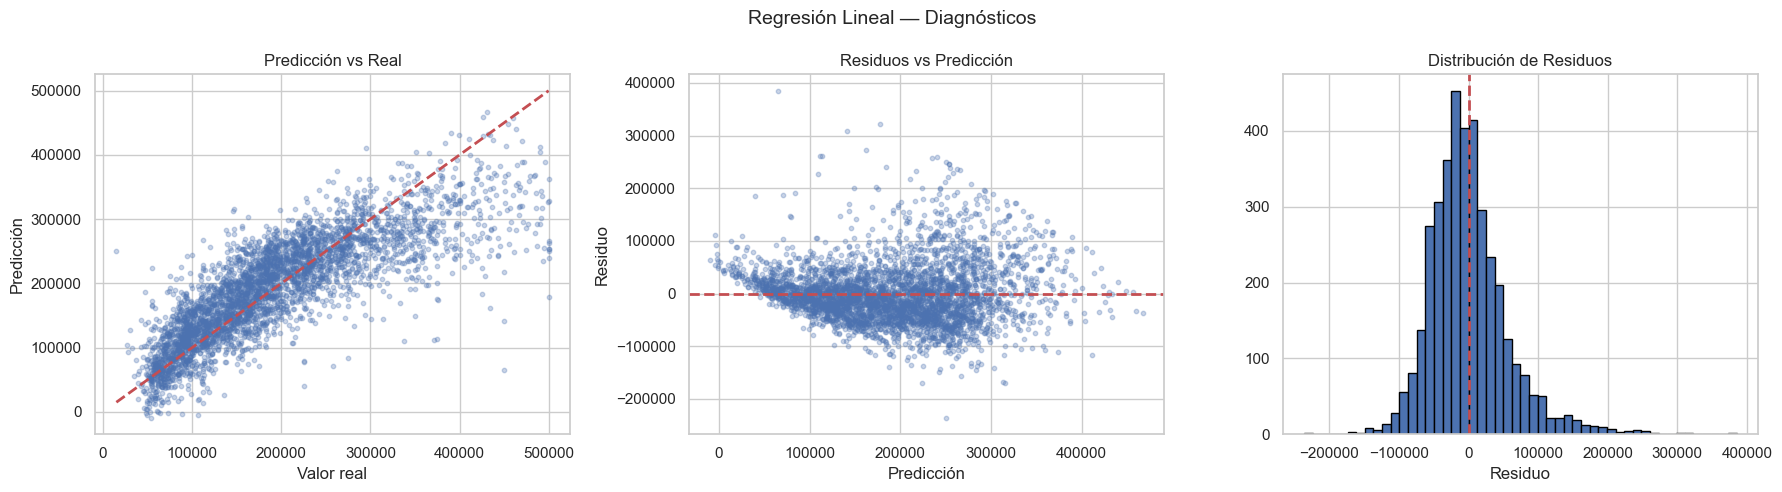

In [12]:
# concepto del challenge: Los números resumen, los gráficos revelan CÓMO falla el modelo.
#   Analizar los RESIDUOS (error por observación) detecta subestimaciones y heterocedasticidad = la variabilidad de los errores no es cte.
 
residuos = y_cal_test - pred_lin # valor real - predicción (cuánto se equivoca el modelo en cada casa).

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regresión Lineal — Diagnósticos', fontsize=14)

# (1) Predicción vs Real: si el modelo fuera perfecto, los puntos caerían sobre la línea roja.
axes[0].scatter(y_cal_test, pred_lin, alpha=0.3, s=10)

# Línea diagonal (y=x) referencia de predicción perfecta.
axes[0].plot([y_cal_test.min(), y_cal_test.max()], [y_cal_test.min(), y_cal_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valor real'); axes[0].set_ylabel('Predicción'); axes[0].set_title('Predicción vs Real')

# (2) Residuos vs Predicción: si se abren en abanico (“cono”), hay heterocedasticidad -> el modelo subestima las casas caras.
axes[1].scatter(pred_lin, residuos, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--', lw=2)  # línea en residuo=0 (error nulo), s
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Residuo'); axes[1].set_title('Residuos vs Predicción')

# (3) Histograma de residuos: si es simétrico alrededor de 0, el error no tiene sesgo.
axes[2].hist(residuos, bins=50, edgecolor='black'); axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Residuo'); axes[2].set_title('Distribución de Residuos')
plt.tight_layout(); plt.show()


## Hallazgos (gráfico de residuos)

- **Gráfico 1 — Predicción vs Real**: los puntos se alinean con la diagonal (en general acierta el orden de magnitud), pero en la esquina alto-valor hay puntos que caen por debajo → el modelo **subestima las casas caras**.
- **Gráfico 2 — Residuos vs Predicción**: se abre en **“cono”** → heterocedasticidad. El error crece con el valor predicho: std ≈ **$38K** en casas baratas vs **$71K** en caras (≈85% más; Levene p≈0 lo confirma). El modelo es menos confiable justo en el rango caro.
- **Gráfico 3 — Histograma**: campana **simétrica alrededor de 0** → sin sesgo global; errores de acierto y de fallo se compensan en promedio.

*Conclusión: RMSE/R² son válidos como resumen global, pero la precisión no es constante — hay que explicar que el error depende del tramo de precio.*


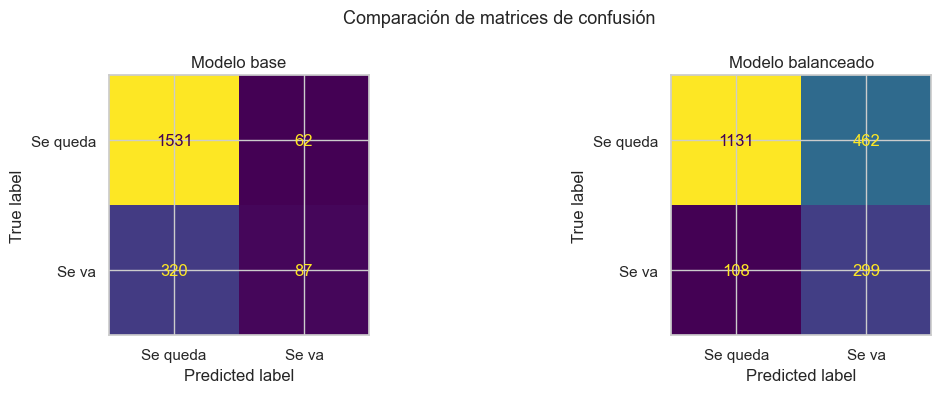


Comparación de errores:
  Base      : Falsos positivos=62, Falsos negativos=320
  Balanceado: Falsos positivos=462, Falsos negativos=108


In [13]:
# Clasificación (matrices de confusión)
# La matriz de confusión muestra exactamente donde se equivoca cada modelo. Al comparar base vs balanceado vemos el trade-off precision/recall.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafica la matriz con colores para el modelo base.
ConfusionMatrixDisplay(confusion_matrix(y_bnk_test, pred_bnk), display_labels=['Se queda', 'Se va']).plot(ax=axes[0], colorbar=False)

axes[0].set_title('Modelo base')

# Ídem para el modelo balanceado.
ConfusionMatrixDisplay(confusion_matrix(y_bnk_test, pred_bnk_bal),
                       display_labels=['Se queda', 'Se va']).plot(ax=axes[1], colorbar=False)

axes[1].set_title('Modelo balanceado')
plt.suptitle('Comparación de matrices de confusión', fontsize=13)
plt.tight_layout(); plt.show()

# Falsos positivos = clientes que no se van pero el modelo marco que si
# Falsos negativos = clientes que si se van pero el modelo marco que no

print('\nComparación de errores:')
print(f'  Base      : Falsos positivos={cm[0,1]}, Falsos negativos={cm[1,0]}')
cm_b = confusion_matrix(y_bnk_test, pred_bnk_bal)
print(f'  Balanceado: Falsos positivos={cm_b[0,1]}, Falsos negativos={cm_b[1,0]}')


## Hallazgos (matrices de confusión)

- **Base — 62 FP vs 320 FN**: acierta mucho en quién se queda (TN=1531, TP=87) pero **pierde en silencio 320 clientes** que sí se fueron → falso negativo = el error caro. Precisión 0.58, Recall 0.21.
- **Balanceado — 462 FP vs 108 FN**: invierte el trade-off. Atrapa casi todos los que se van (FN 320 → 108, Recall 0.73) a costa de más falsas alarmas (FP 62 → 462, Precisión 0.39).
- **Lectura de negocio**: si perder un cliente cuesta más que una oferta innecesaria → elegir el balanceado; el base solo conviene si cada alerta tiene costo alto y hay que ser selectivo.


## Interpretación de coeficientes

Se analiza el peso que el modelo le asignó a cada feature de California, en unidades comparables gracias al `StandardScaler` del pipeline: cada coeficiente expresa el cambio en dólares por cada desviación estándar extra de esa feature, manteniendo el resto constante.


In [14]:
nombres_cal = lin_pipe.named_steps['prep'].get_feature_names_out() # del pipeline trae los nombres reales de colum. procesadas

coefs_cal = lin_pipe.named_steps['model'].coef_ # del modelo entrenado extrae los coef.

tabla_coef = pd.DataFrame({'feature': nombres_cal, 'coeficiente': coefs_cal}) # df relac. feature con su coef.

tabla_coef['feature'] = tabla_coef['feature'].str.replace(r'^(num|cat)__', '', regex=True) #limpieza de nombres 

tabla_coef['abs'] = tabla_coef['coeficiente'].abs() # colum. temp. para medir impacto de los coef.

tabla_coef = tabla_coef.sort_values('abs', ascending=False).drop(columns='abs') # ordena la tabla por impacto

print(f'Intercepto (B0): {lin_pipe.named_steps["model"].intercept_:,.0f} $') # extrae la base (intercepto) del modelo

print(tabla_coef.to_string(index=False))

# Seccion Churn

coefs_bnk = pd.DataFrame({'feature': X_bnk.columns,
                          'coef_base': logreg.coef_[0],
                          'coef_balanceado': logreg_bal.coef_[0]}) # comp. de modelo base y balanc. con features y coef.

coefs_bnk['abs'] = coefs_bnk['coef_base'].abs()

coefs_bnk = coefs_bnk.sort_values('abs', ascending=False).drop(columns='abs')

coefs_bnk['odds_base'] = np.exp(coefs_bnk['coef_base']) # conv. el coef. base en un mult. de riesgo

print(f'\nChurn — Intercepto (B0): base={logreg.intercept_[0]:.3f} | balanceado={logreg_bal.intercept_[0]:.3f}')
print(coefs_bnk.to_string(index=False))


Intercepto (B0): 205,032 $
                   feature   coeficiente
    ocean_proximity_ISLAND 149264.957588
             median_income  49522.084341
                households  42909.564792
    ocean_proximity_INLAND -41099.049493
            total_bedrooms -35566.399401
ocean_proximity_NEAR OCEAN  26486.016161
         bedrooms_per_room  23700.633445
  population_per_household -19366.534378
       rooms_per_household  15976.721794
              age_x_income  13630.543291
                geo_zone_5 -13408.590075
                geo_zone_3 -12124.184551
                geo_zone_2 -10981.479573
  ocean_proximity_NEAR BAY -10491.174946
                geo_zone_7 -10214.568907
                population  -9785.832773
                geo_zone_6  -8255.901121
               total_rooms   6861.385797
                geo_zone_4  -4984.698999
                geo_zone_1   1239.206132
        housing_median_age   -736.671362

Churn — Intercepto (B0): base=-1.696 | balanceado=-0.323
             

## Interpretación de coeficientes

Features estandarizadas: cada coeficiente = cambio por **+1 desviación estándar (DS)**, con el resto constante. En churn (logística) `exp(coef)` = multiplicador del riesgo de fuga por cada +1 DS.

**California (cambio en $ del precio):**

- `median_income` **+49,522** es dominante; su señal se reparte con `age_x_income` **+13,631** (casa vieja *y* rica vale más que la suma).
- Ubicación la resumen las **zonas K-Means** (sin lat/lon): `geo_zone_5` **-13,409**, `geo_zone_3` **-12,124**, `geo_zone_2` **-10,981** y `geo_zone_7` **-10,215** bajan sobre `geo_zone_0`; solo `geo_zone_1` suma (**+1,239**).
- Ratios: `bedrooms_per_room` **+23,701** y `rooms_per_household` **+15,977** suben; `population_per_household` **-19,367** baja (más gente por hogar → distritos más densos y baratos). `INLAND` **-41,099** vs `NEAR OCEAN` **+26,486** (asumen ahora la señal espacial que antes tenía lat/lon).
- 🚩 `ocean_proximity_ISLAND` **+149,265** con <1% de datos → poca evidencia, no regla de mercado.

**Churn (positivo = más fuga):**

| Feature | coef | exp(b) | Lectura |
|---|---|---|---|
| `Balance_x_NumOfProducts` | +0.87 | **2.4×** | +1 DS en dinero por producto → +140% riesgo |
| `Age` | +0.55 | **1.7×** | clientes mayores se van más |
| `Geography_Germany` | +0.33 | **1.4×** | radicado en Alemania → más riesgo |
| `Balance` | -0.67 | 0.5× | más saldo → menos fuga (dinero atado al banco) |
| `Tenure_per_Age` | -0.60 | 0.55× | más años en el banco → más leal |
| `NumOfProducts` | -0.52 | 0.6× | más productos → más atado |
| `IsActiveMember` | -0.51 | 0.6× | miembro activo → efecto protector |

Los **signos son casi idénticos** en base y balanceado: `class_weight='balanced'` recalibra el umbral, no cambia el ranking de riesgo.

## Interpretación humana

¿RMSE más cerca de $5 o de $500K? → **De $500K**: el modelo se equivoca en promedio **$55,829** sobre un rango real de **$15K–$500K** (error relativo a la volatilidad = **0.57** < 1 → mejor que adivinar la media constante). $5 sería predicción perfecta, imposible con datos tabulares. El RMSE no miente: faltaba contexto de escala.


In [15]:
#el RMSE está más cerca de $5 (predicción de genio) o de $500K (predicción mala). Debemos CONECTUALIZAR la escala.
# Error relativo: RMSE / std(y). Si <1, el modelo es mejor que simplemente adivinar la media.

error_rel = rmse_lin / max(np.std(y_cal), 1e-9) # error del modelo / desv. estandar 

# Rango real de precios en test (de ~15K a ~500K).
print(f'Rango del target (test): [{y_cal_test.min():,.0f} $, {y_cal_test.max():,.0f} $]')

# RMSE en dólares: el error promedio del modelo por casa.
print(f'RMSE (Regresión Lineal): {rmse_lin:,.0f} $')

# Respuesta del challenge: ~$55K está mucho más cerca de $500K que de $5.
print(f'¿Más cerca de $5 o de $500K? → Definitivamente MÁS CERCA de $500K.')

# Nota: <1 => mejor que la media constante. ~0.62 => explica buena parte de la volatilidad.
print(f'RMSE relativo a la volatilidad del precio (std): {error_rel:.2f} (< 1 = mejor que adivinar la media)')


Rango del target (test): [14,999 $, 500,000 $]
RMSE (Regresión Lineal): 55,829 $
¿Más cerca de $5 o de $500K? → Definitivamente MÁS CERCA de $500K.
RMSE relativo a la volatilidad del precio (std): 0.57 (< 1 = mejor que adivinar la media)


### Precision, Recall y Accuracy — el *cliente que se va*

Clase positiva = **1 = “abandona el banco”**.

- **Accuracy** = aciertos totales. Con 79.6% de “se queda”, un modelo que nunca marca fuga logra ~0.80 sin atrapar a nadie → **puede mentir**.
- **Precision** = de los marcados como fugables, cuántos lo eran → alertas pocas y certeras (evita falsas alarmas).
- **Recall** = de los que se van, cuántos atrapó → bajo = clientes perdidos en silencio (falso negativo).

En retención se prioriza **Recall**: una oferta innecesaria cuesta menos que perder al cliente. Ese trade-off es lo que muestran base vs balanceado.


In [ ]:
print("REFLEXIÓN SOBRE PRECISION vs RECALL EN BANK CHURN:\n")
# Recall base ~0.21 => solo atrapa al 21% de los que realmente se iban.
print(f"- Recall (base) = {rec:.2f} → detecta al {rec*100:.0f}% de los que realmente se iban;")
# El 81% restante se va sin ser detectado (falso negativo = cliente perdido).
print(f"  el {(1-rec)*100:.0f}% restante se marcha sin ser señalado (falso negativo = CLIENTE PERDIDO).")
# Precision base ~0.58 => de todos los marcados como “se van”, 58% lo eran (42% falsa alarma).
print(f"- Precision (base) = {prec:.2f} → del {(pred_bnk==1).sum()} marcados como fugables,")
print(f"  solo el {prec*100:.0f}% lo eran; el resto es falsa alarma.")
# Accuracy base ~0.81 => alto, pero oculta el bajo recall.
print(f"- Accuracy (base) = {acc:.2f} → el {acc*100:.0f}% de TODAS las predicciones fueron correctas.")
# El balanceado sube recall (0.70) pero baja precisión (0.39).
print(f"\n- Balanceado: Recall={rec_b:.2f} (más fugables atrapados) a costa de Precision={prec_b:.2f}.")
print("  La elección del modelo depende del costo de cada error, no de un único número.")


REFLEXIÓN SOBRE PRECISION vs RECALL EN BANK CHURN:

- Recall (base) = 0.21 → detecta al 21% de los que realmente se iban;
  el 79% restante se marcha sin ser señalado (falso negativo = CLIENTE PERDIDO).
- Precision (base) = 0.58 → del 149 marcados como fugables,
  solo el 58% lo eran; el resto es falsa alarma.
- Accuracy (base) = 0.81 → el 81% de TODAS las predicciones fueron correctas.

- Balanceado: Recall=0.73 (más fugables atrapados) a costa de Precision=0.39.
  La elección del modelo depende del costo de cada error, no de un único número.


## Conclusiones

### Regresión — California

| Modelo | RMSE | R² |
|--------|------|------|
| Regresión Lineal | $55,829 | 0.6717 |

Explica el **67.2%** de la variación de precios, con error promedio de **$55,829** sobre un rango real de $15K–$500K.

### Clasificación — Bank Churn

| Metrica | Modelo base | Modelo balanceado |
|---------|-------------|-------------------|
| Accuracy | 0.8090 | 0.7150 |
| Precision | 0.5839 | 0.3929 |
| Recall | 0.2138 | 0.7346 |

El desbalance hace que **Accuracy engañe**: base 0.81 con Recall 0.21 (escapa el 79% de las bajas); balanceado sube Recall a 0.73 sacrificando Precision.

### La decisión que importa — costo del error

Base: Precision alta (0.58) · Recall 0.21 → alertas pocas y certeras (recursos limitados). 
Balanceado: Recall 0.73 · Precision 0.39 → perder un cliente cuesta más que una falsa alarma (escenario real en banca minorista). Ambos comparten F1 bajo (~0.31 / ~0.52).

### Qué funcionó — California

- `median_income` es el predictor dominante (**+49,522** por desviación estándar), coherente con la correlación alta del EDA.
- La receta de **feature engineering** rinde: ratios curados + `age_x_income` + zonas **K-Means** (sin lat/lon). Resultado: **RMSE $55,829 / R² 0.6717**.
- Churn: **cross features** con lectura económica y **Recall 0.73** con el balanceado.

### Limitaciones — California

- Heterocedasticidad: **subestima las casas de alto valor** — los 3 gráficos de diagnóstico revelan que el error crece con el valor predicho; es la naturaleza de un modelo lineal frente al mercado de lujo.
- `ocean_proximity_ISLAND` (+$149,265, <1% datos): poca evidencia para estimarlo con confianza; señal débil, no regla de mercado.
- Accuracy solo no basta con clases desbalanceadas → Precision/Recall y matriz de confusión (churn).

### Errores que me humillaron

1. **RMSE sin escala** (CA): $55K “parece mucho” hasta ver el rango real ($15K–$500K): error relativo razonable.
2. **Confiar en Accuracy** (churn): 0.81 con Recall 0.21 no atrapaba bajas.
3. **No verificar generalización** (ambos): un modelo puede memorizarse las respuestas del entrenamiento (overfitting) y fallar con datos nuevos. Comparé RMSE en **train vs test** (train=$56,791, test=$55,829, Δ<5%) → el test no fue peor que el train, el modelo **aprendió el patrón y no memoriza**.

### Qué haría distinto

- Verificar rangos y distribución (`.describe()`) de cada feature nueva antes de integrarla al pipeline (un fallo al aplicar `.astype(int)` a un ratio truncó datos en un intento previo de feature engineering).
- Heterocedasticidad: probar **log(target)** o modelos **no lineales** (el mejor resultado público en Kaggle para este problema ronda ~$48K en RMSE) para California.
- Churn: ajustar el **umbral** (<0.5) o probar **SMOTE** para subir recall sin destruir precision.

SMOTE: técnica que crea clientes ficticios "falsos pero realistas" para que el modelo tenga suficientes ejemplos de personas que se van y aprenda a detectarlas a tiempo sin volverse paranoico.

---

**El RMSE me enseñó humildad.** No busco predicción perfecta; busco evaluación honesta, decisiones consistentes y métricas contextualizadas. El modelo es el instrumento; el humano decide la política.